# ECG signal preprocessing pipeline

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from _nb_exploratory_analysis import (
    summarize_signal,
    summarize_signal_quality,
)
from _nb_preprocessing import (
    compare,
    plot_preprocessing_steps,
)

from ecg_waveform.config import (
    LUDB_DIR,
    MITDB_DIR,
    ensure_directories,
    get_ludb_record_names,
    get_mitdb_record_names,
    load_yaml,
)
from ecg_waveform.data import WFDBLoader
from ecg_waveform.preprocessing import (
    Preprocessor,
)
from ecg_waveform.visualization import (
    plot_fft,
    plot_psd,
    set_style,
)

ensure_directories()

set_style()

In [43]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [44]:
mitdb_loader = WFDBLoader(MITDB_DIR, "atr")
mitdb_record = mitdb_loader[get_mitdb_record_names()[0]]
mitdb_signal = mitdb_record.get_signal(0).resample(200)

R_PEAK_SYMBOLS = load_yaml("annotation_labels.yaml")["r_peaks"]

mitdb_r_peaks = mitdb_signal.annotation.filter(R_PEAK_SYMBOLS)

In [45]:
LEADS = (
    "i", "ii", "iii", "avr", "avl", "avf",
    "v1", "v2", "v3", "v4", "v5", "v6",
)

ludb_loader = WFDBLoader(LUDB_DIR, {lead: lead for lead in LEADS})
ludb_record = ludb_loader[get_ludb_record_names()[0]]
ludb_signal = ludb_record.get_signal(1).resample(200)

R_PEAK_SYMBOLS = load_yaml("annotation_labels.yaml")["r_peaks"]

ludb_r_peaks = ludb_signal.annotation.filter(R_PEAK_SYMBOLS)

In [46]:
config = {
    "steps": [
        {"name": "median_baseline_filter"},
        {"name": "notch_filter", "params": {"freq": 50.0}},
        {"name": "notch_filter", "params": {"freq": 60.0}},
        {"name": "butterworth_filter", "params": {"low_cutoff": 0.5, "high_cutoff": 40.0, "order": 4}},
    ]
}

preprocessor = Preprocessor.from_config(config)

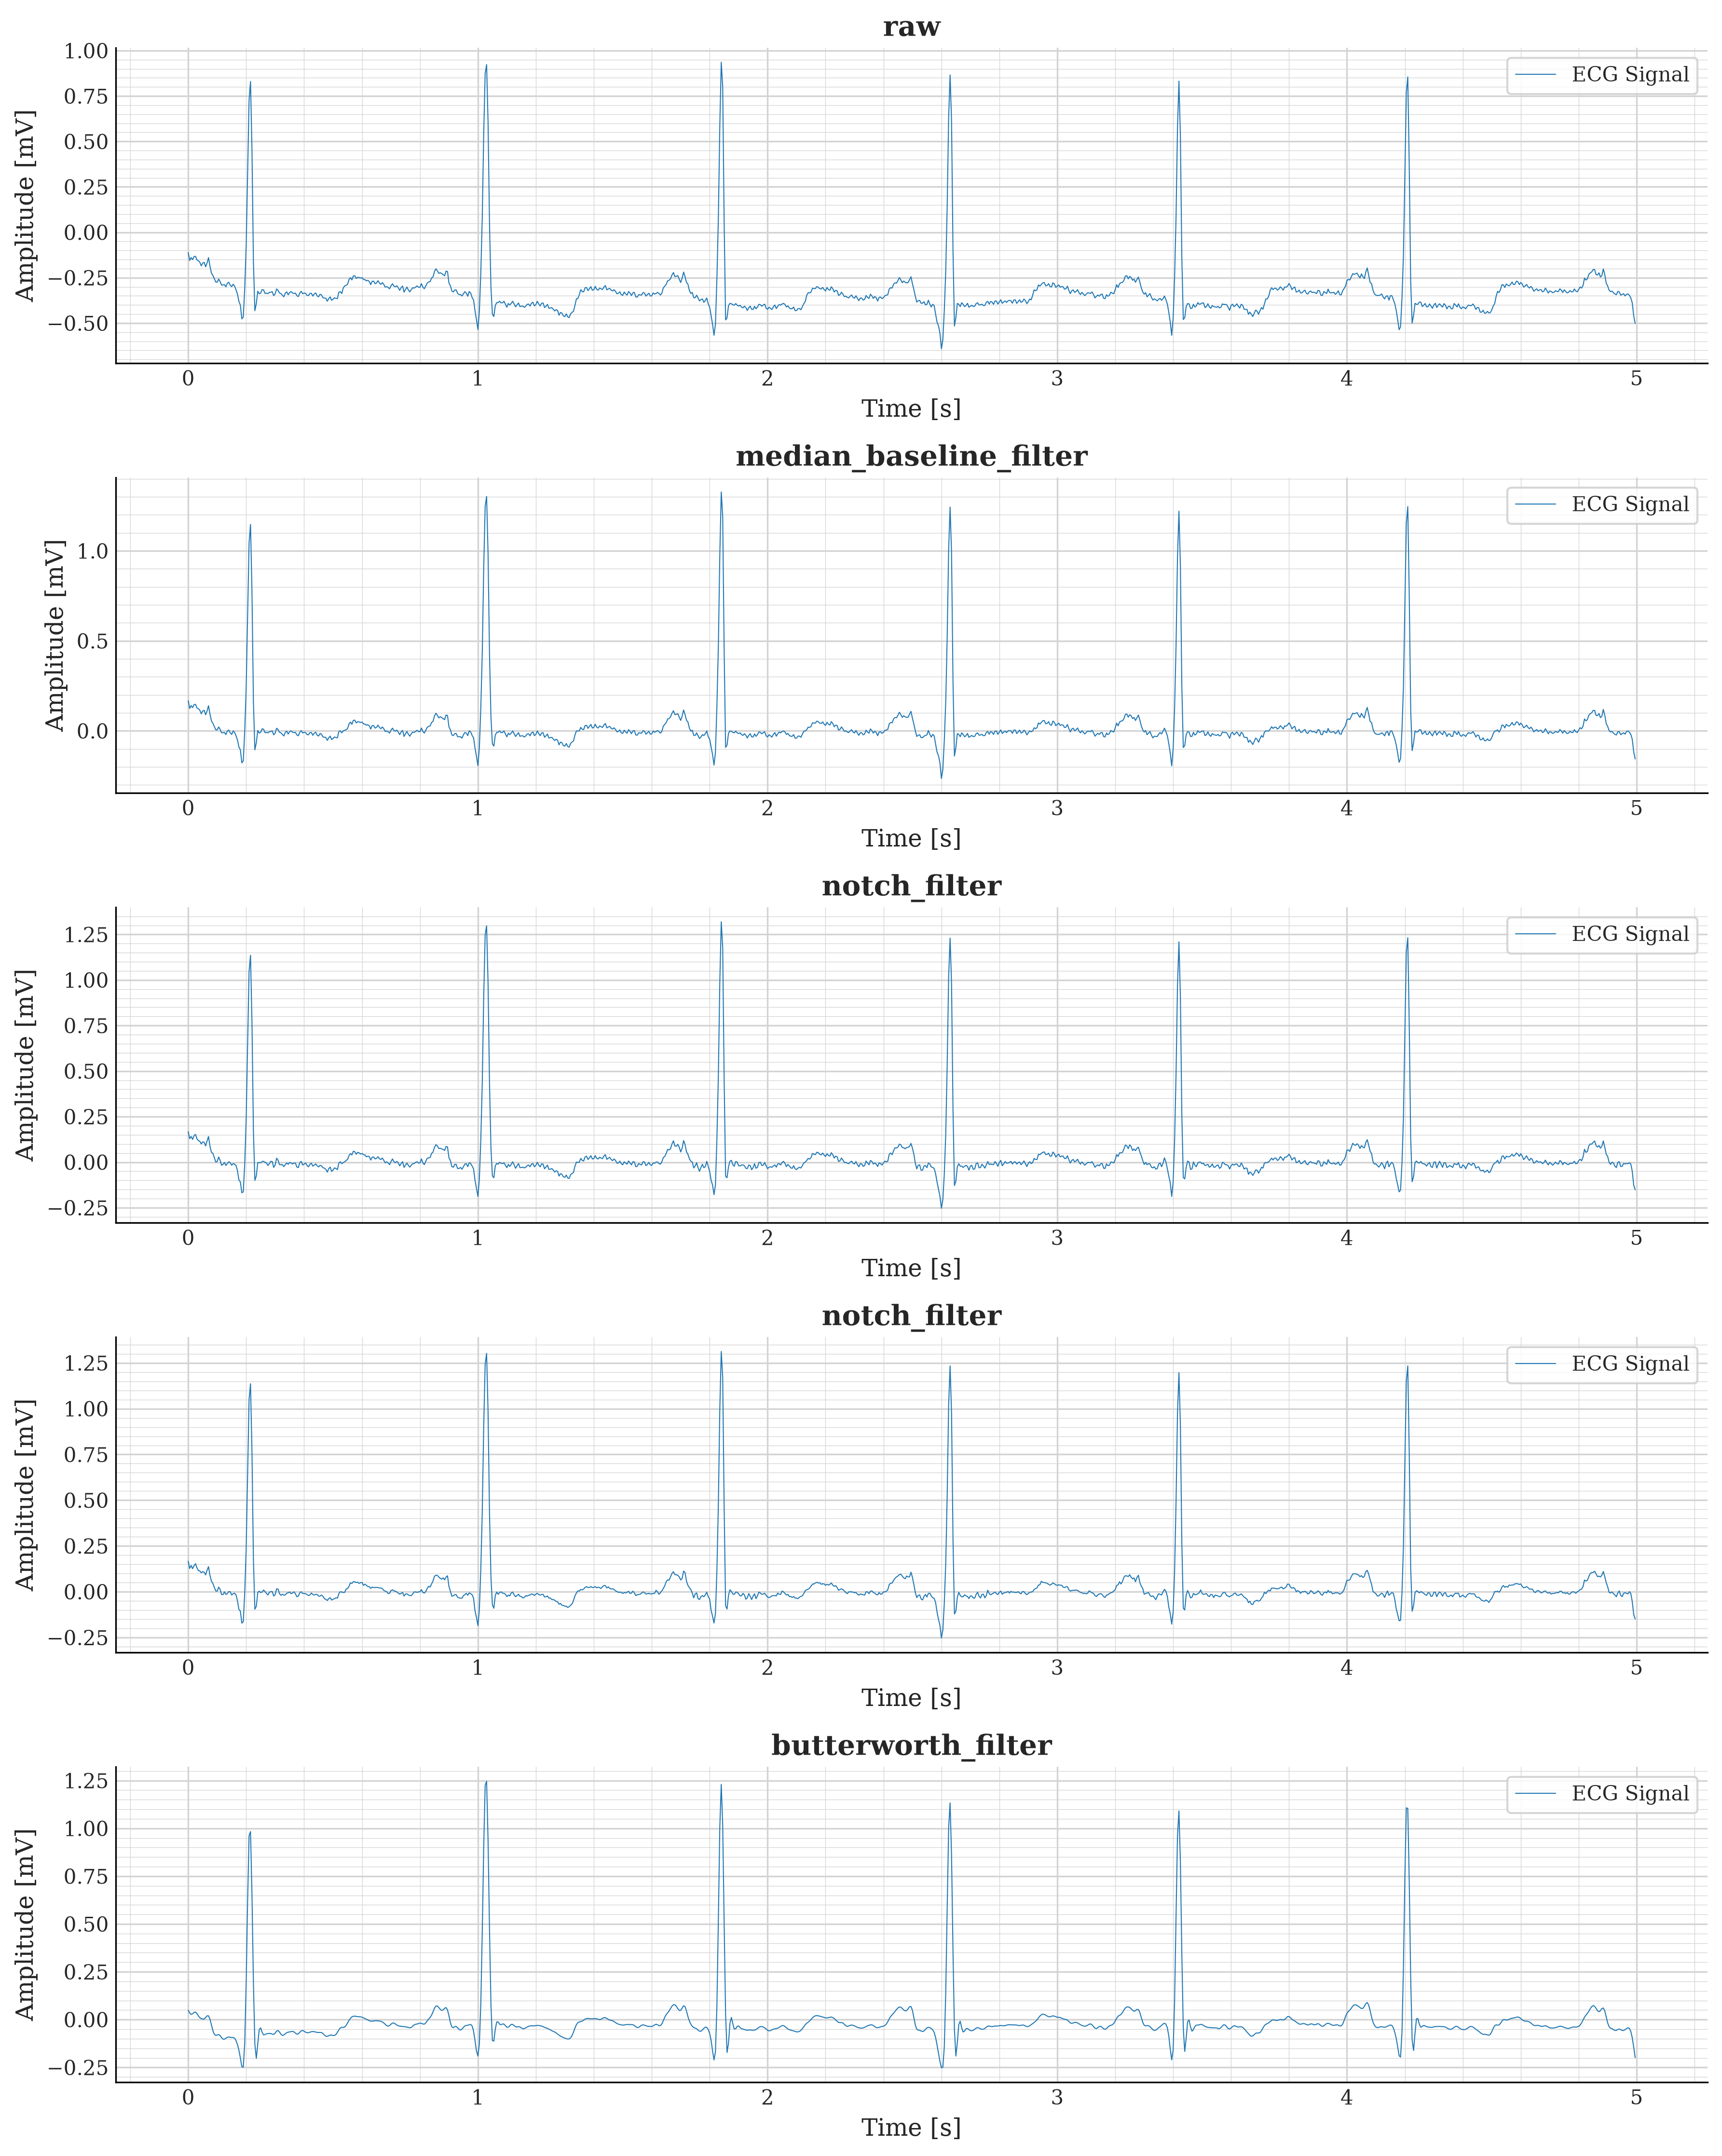

In [47]:
stages = preprocessor.run_stepwise(mitdb_signal)
fig, axes = plot_preprocessing_steps(stages, start_sec=0, interval_sec=5, show_annotation=False)

In [48]:
clean_mitdb_signal = preprocessor(mitdb_signal)

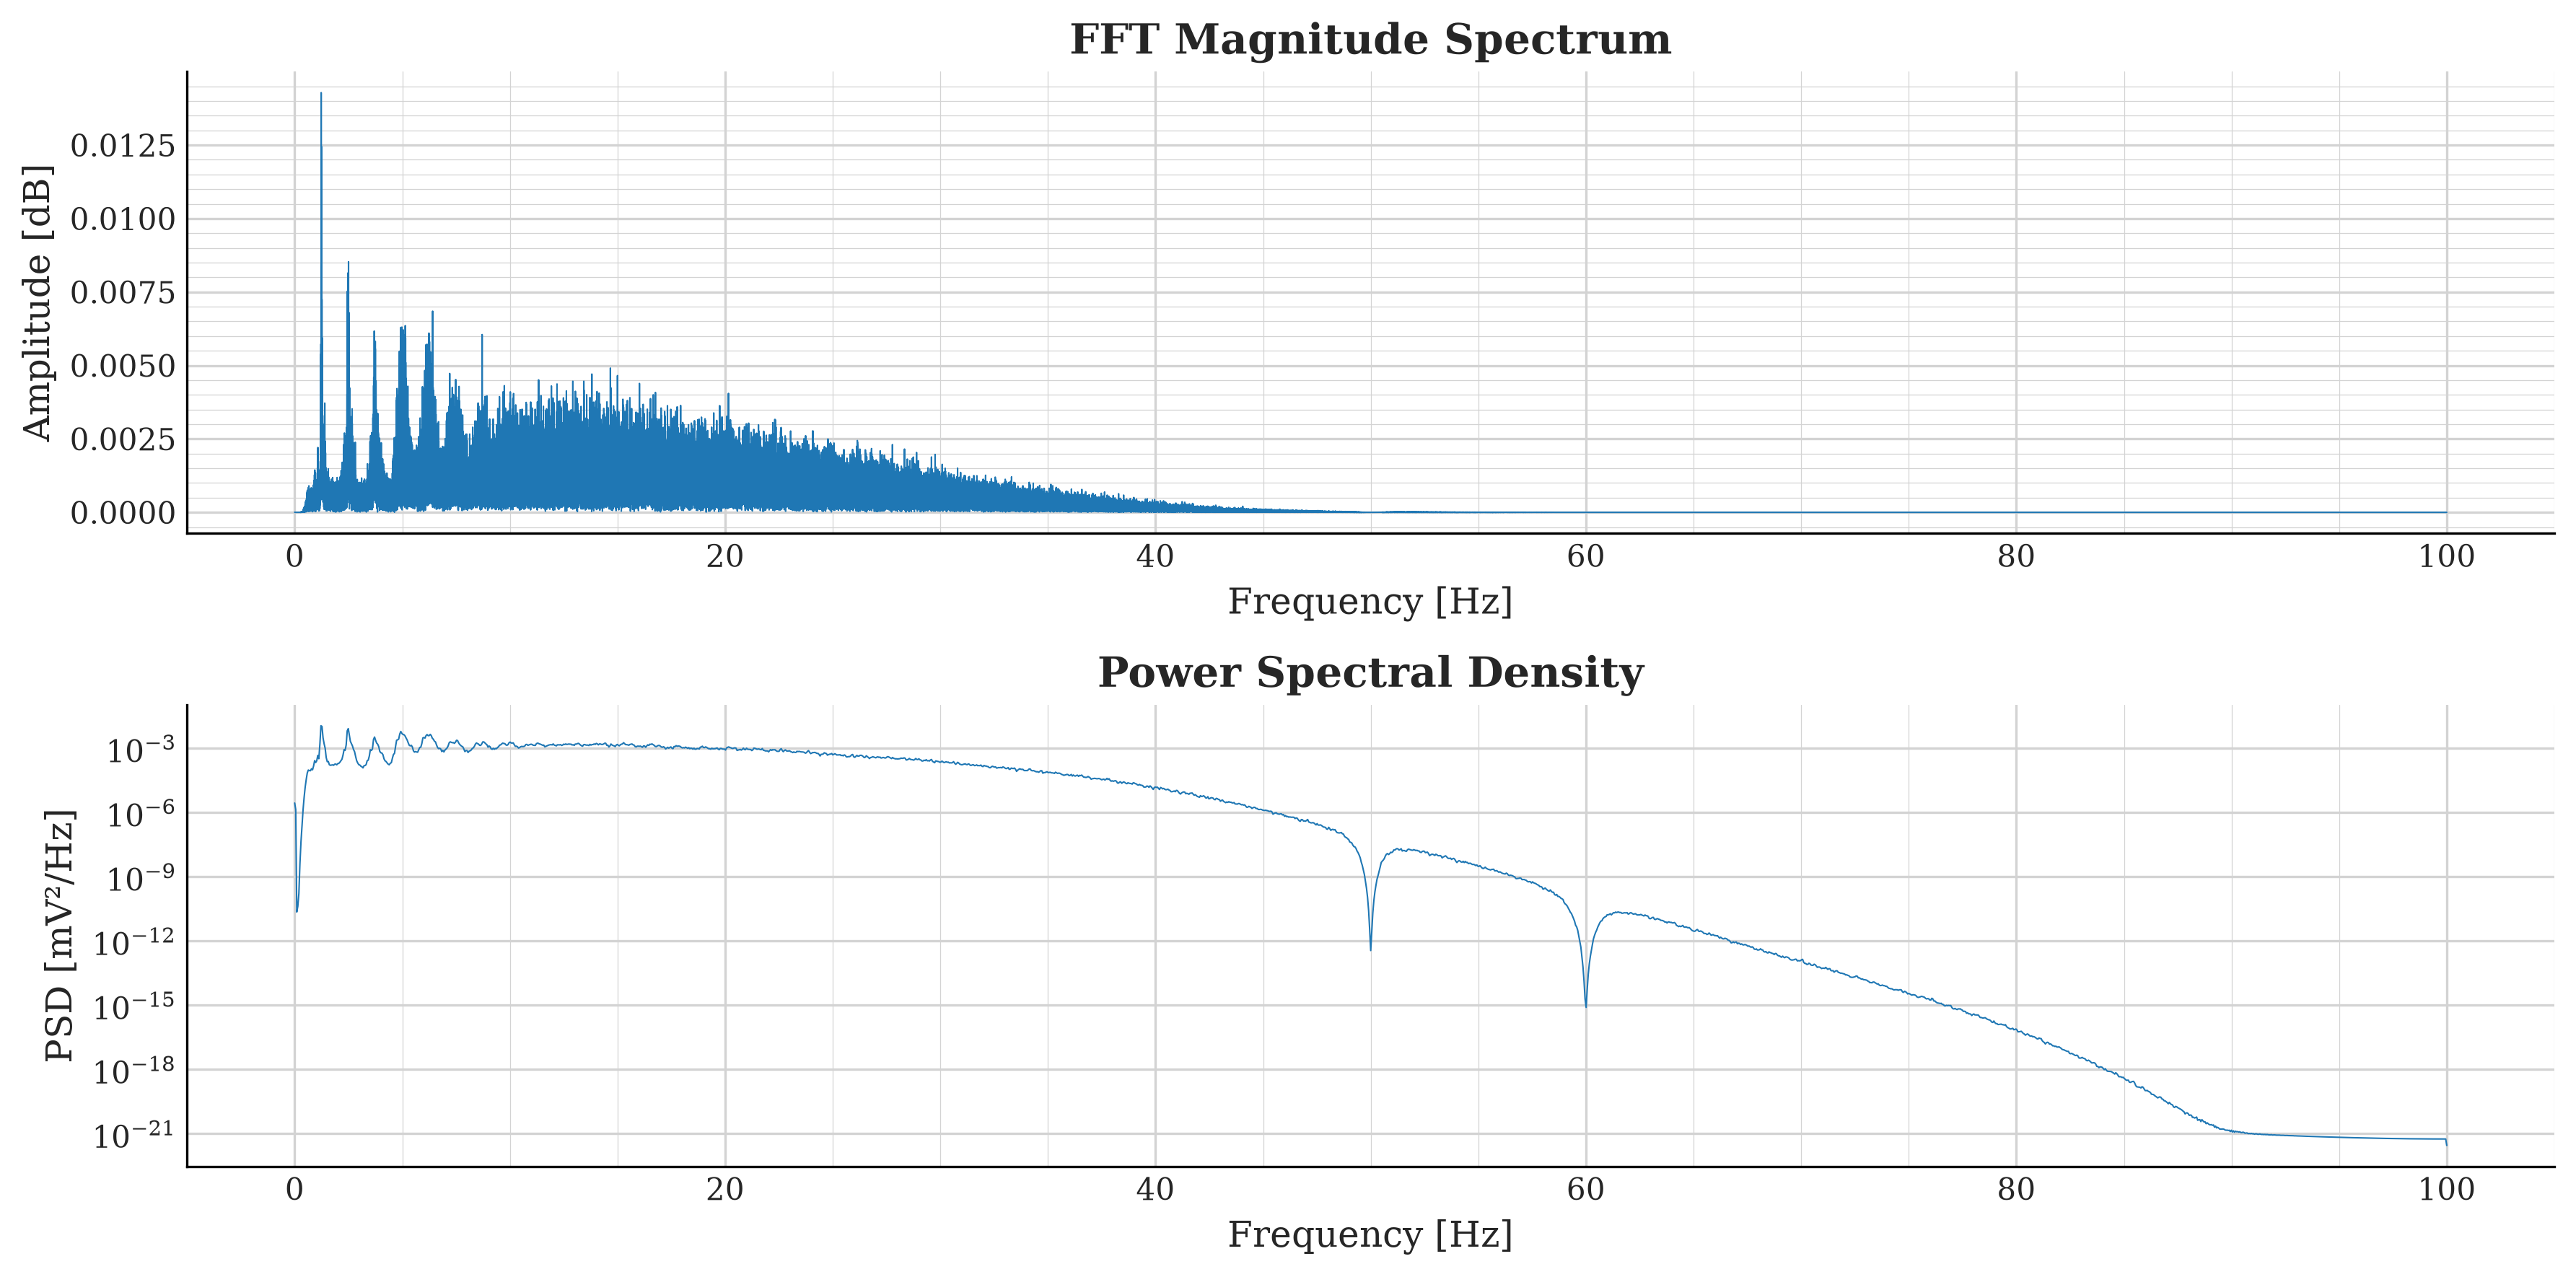

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

plot_fft(clean_mitdb_signal, ax=ax1)
plot_psd(clean_mitdb_signal, ax=ax2)

plt.tight_layout()
plt.show()

In [50]:
raw = summarize_signal(mitdb_signal)
clean = summarize_signal(clean_mitdb_signal)

compare(raw, clean)

Raw                       Clean         
             Property    Value           Property    Value
0           Lead name     MLII          Lead name     MLII
1    Sample rate (Hz)      200   Sample rate (Hz)      200
2   Number of samples   361112  Number of samples   361112
3        Duration (s)  1805.56       Duration (s)  1805.56
4            Min (mV)    -2.71           Min (mV)    -2.44
5            Max (mV)    1.431           Max (mV)    1.728
6           Mean (mV)   -0.306          Mean (mV)     -0.0
7            Std (mV)    0.193           Std (mV)    0.182
8       Dynamic range    4.141      Dynamic range    4.168
9   Outlier ratio (%)      0.0  Outlier ratio (%)      0.0
10        NaN Samples        0        NaN Samples        0
11      NaN ratio (%)      0.0      NaN ratio (%)      0.0

In [51]:
raw = summarize_signal_quality(mitdb_signal)
clean = summarize_signal_quality(clean_mitdb_signal)

compare(raw, clean)

Raw                                    Clean  \
                          Property   Value                         Property   
0                     Kurtosis SQI  25.440                     Kurtosis SQI   
1                    QRS Power SQI   0.445                    QRS Power SQI   
2  Powerline Noise Ratio (50.0 Hz)   0.001  Powerline Noise Ratio (50.0 Hz)   
3  Powerline Noise Ratio (60.0 Hz)   0.001  Powerline Noise Ratio (60.0 Hz)   
4            Baseline Wander Ratio   0.880            Baseline Wander Ratio   
5                   Flatline Ratio   0.000                   Flatline Ratio   

           
    Value  
0  30.869  
1   0.460  
2   0.000  
3   0.000  
4   0.040  
5   0.000

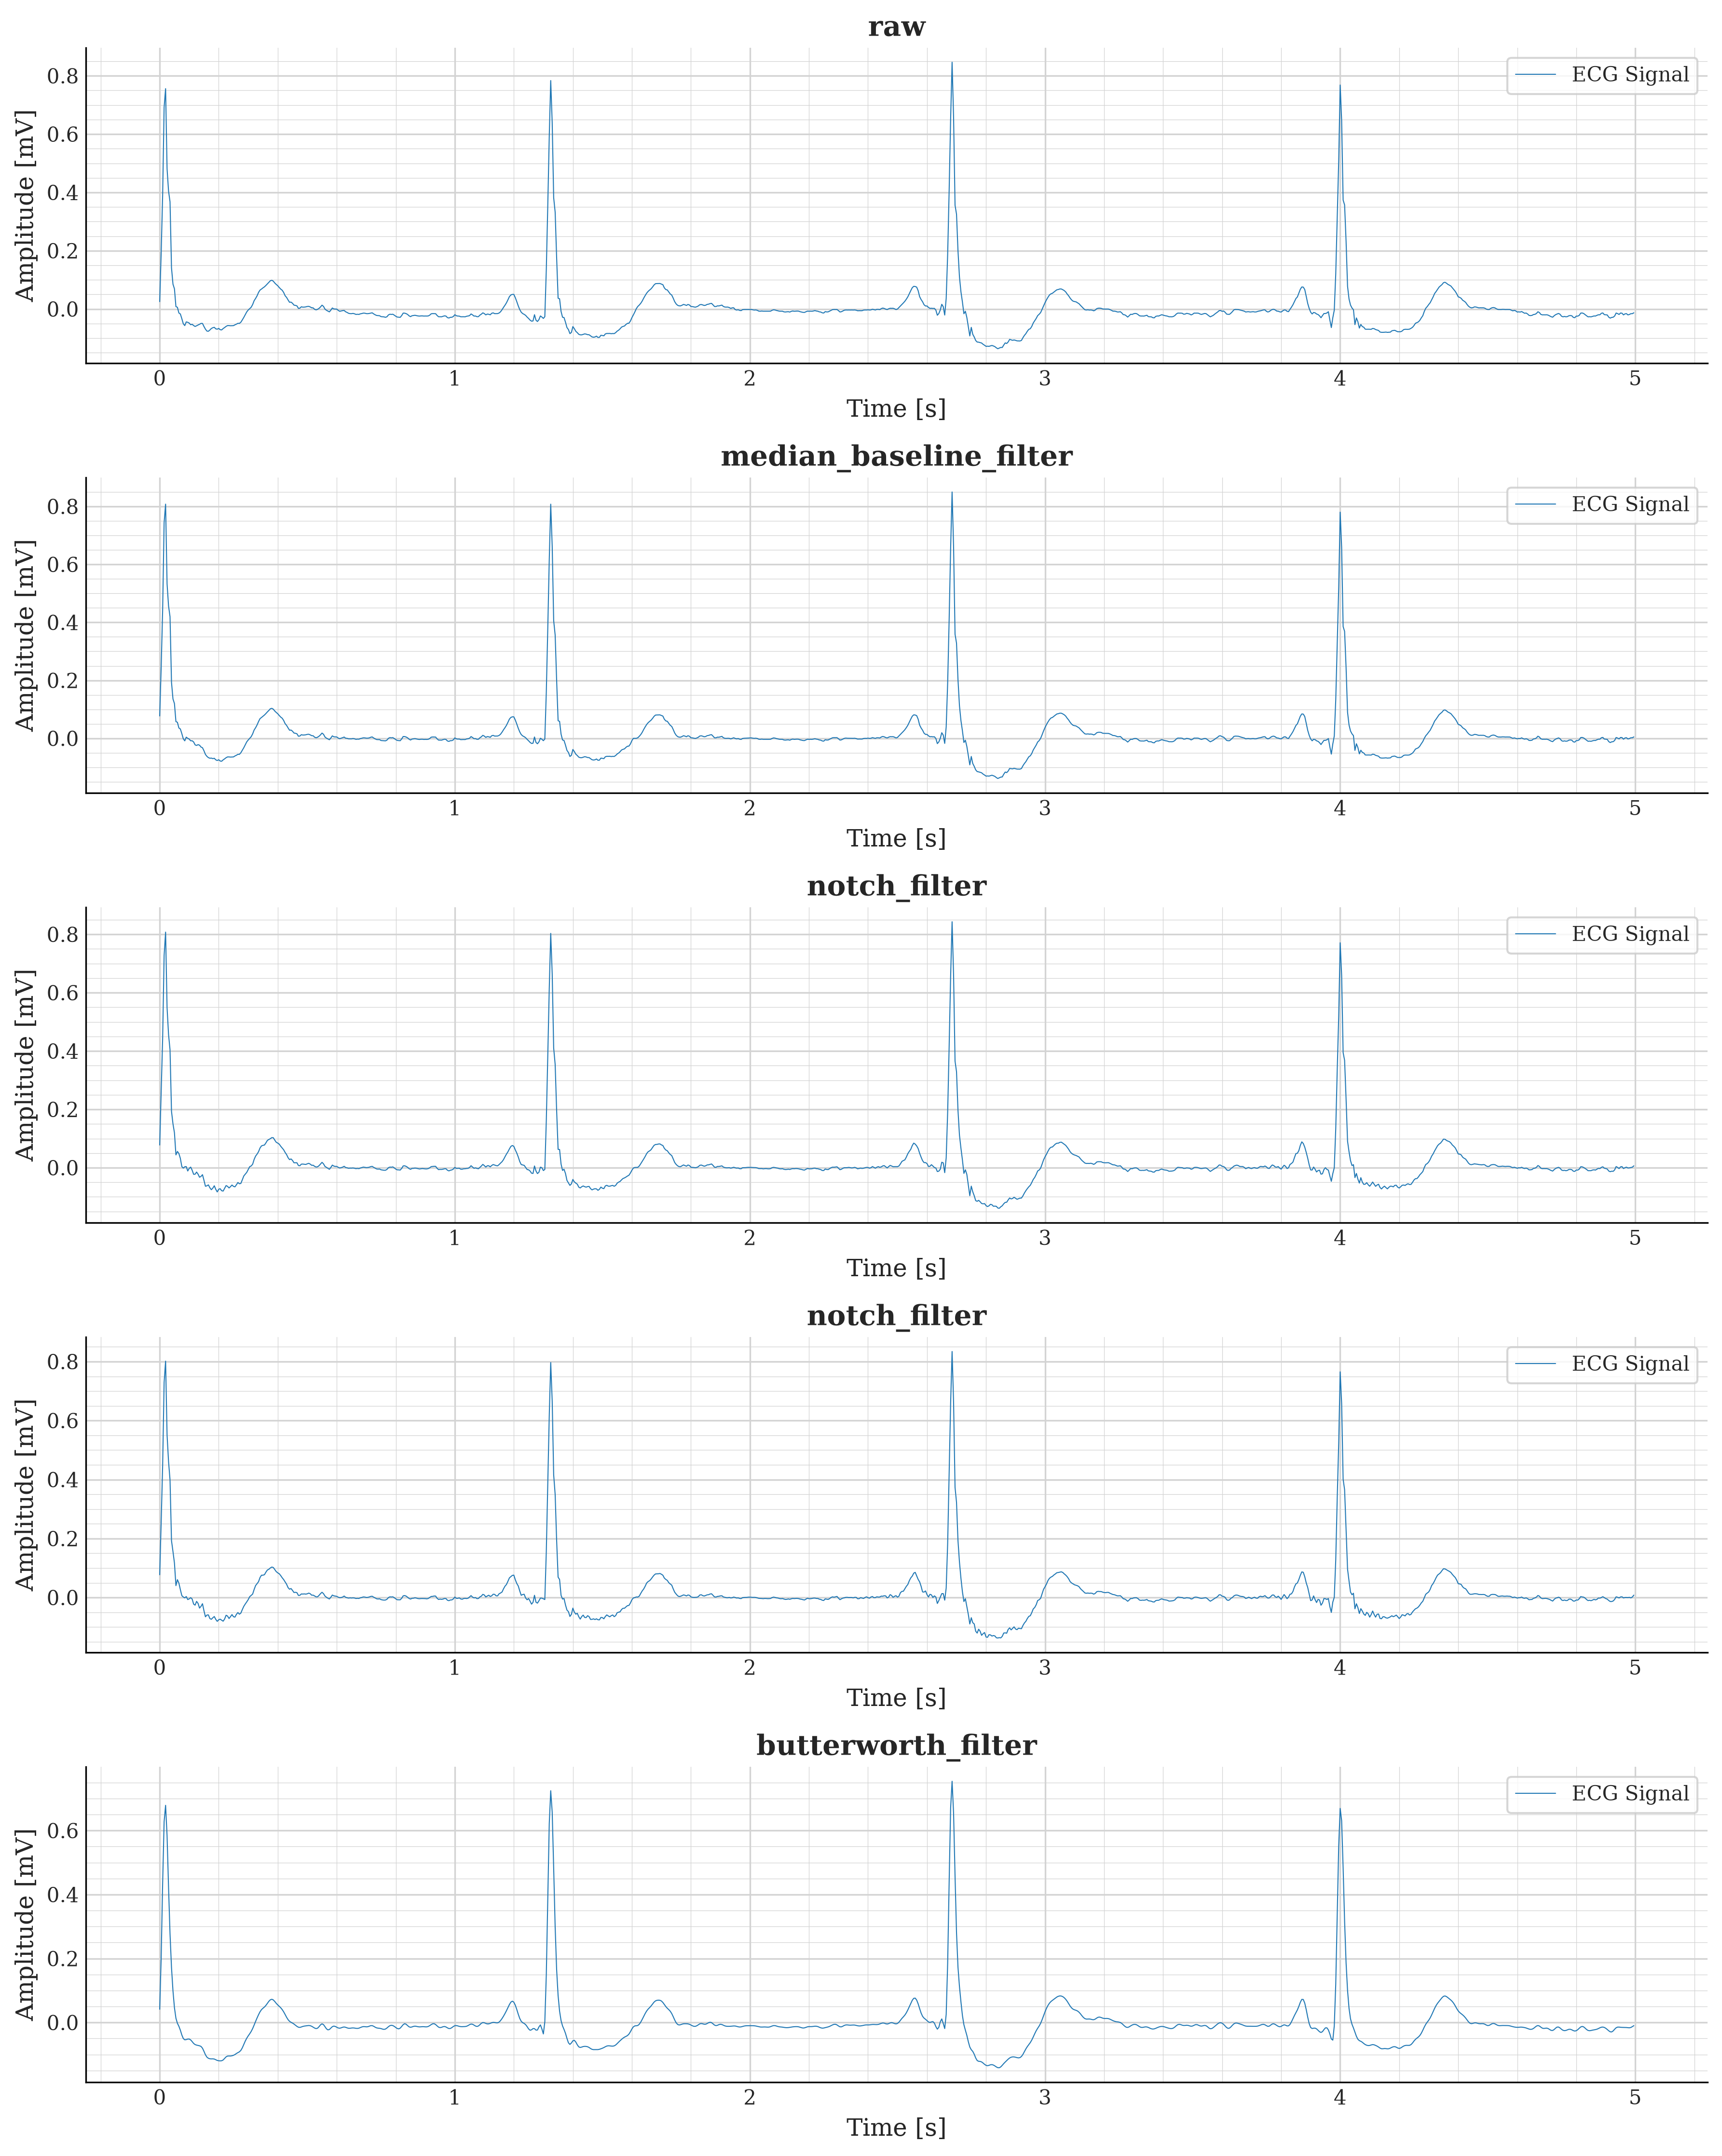

In [52]:
stages = preprocessor.run_stepwise(ludb_signal)
fig, axes = plot_preprocessing_steps(stages, start_sec=0, interval_sec=5, show_annotation=False)

In [53]:
clean_ludb_signal = preprocessor(ludb_signal)

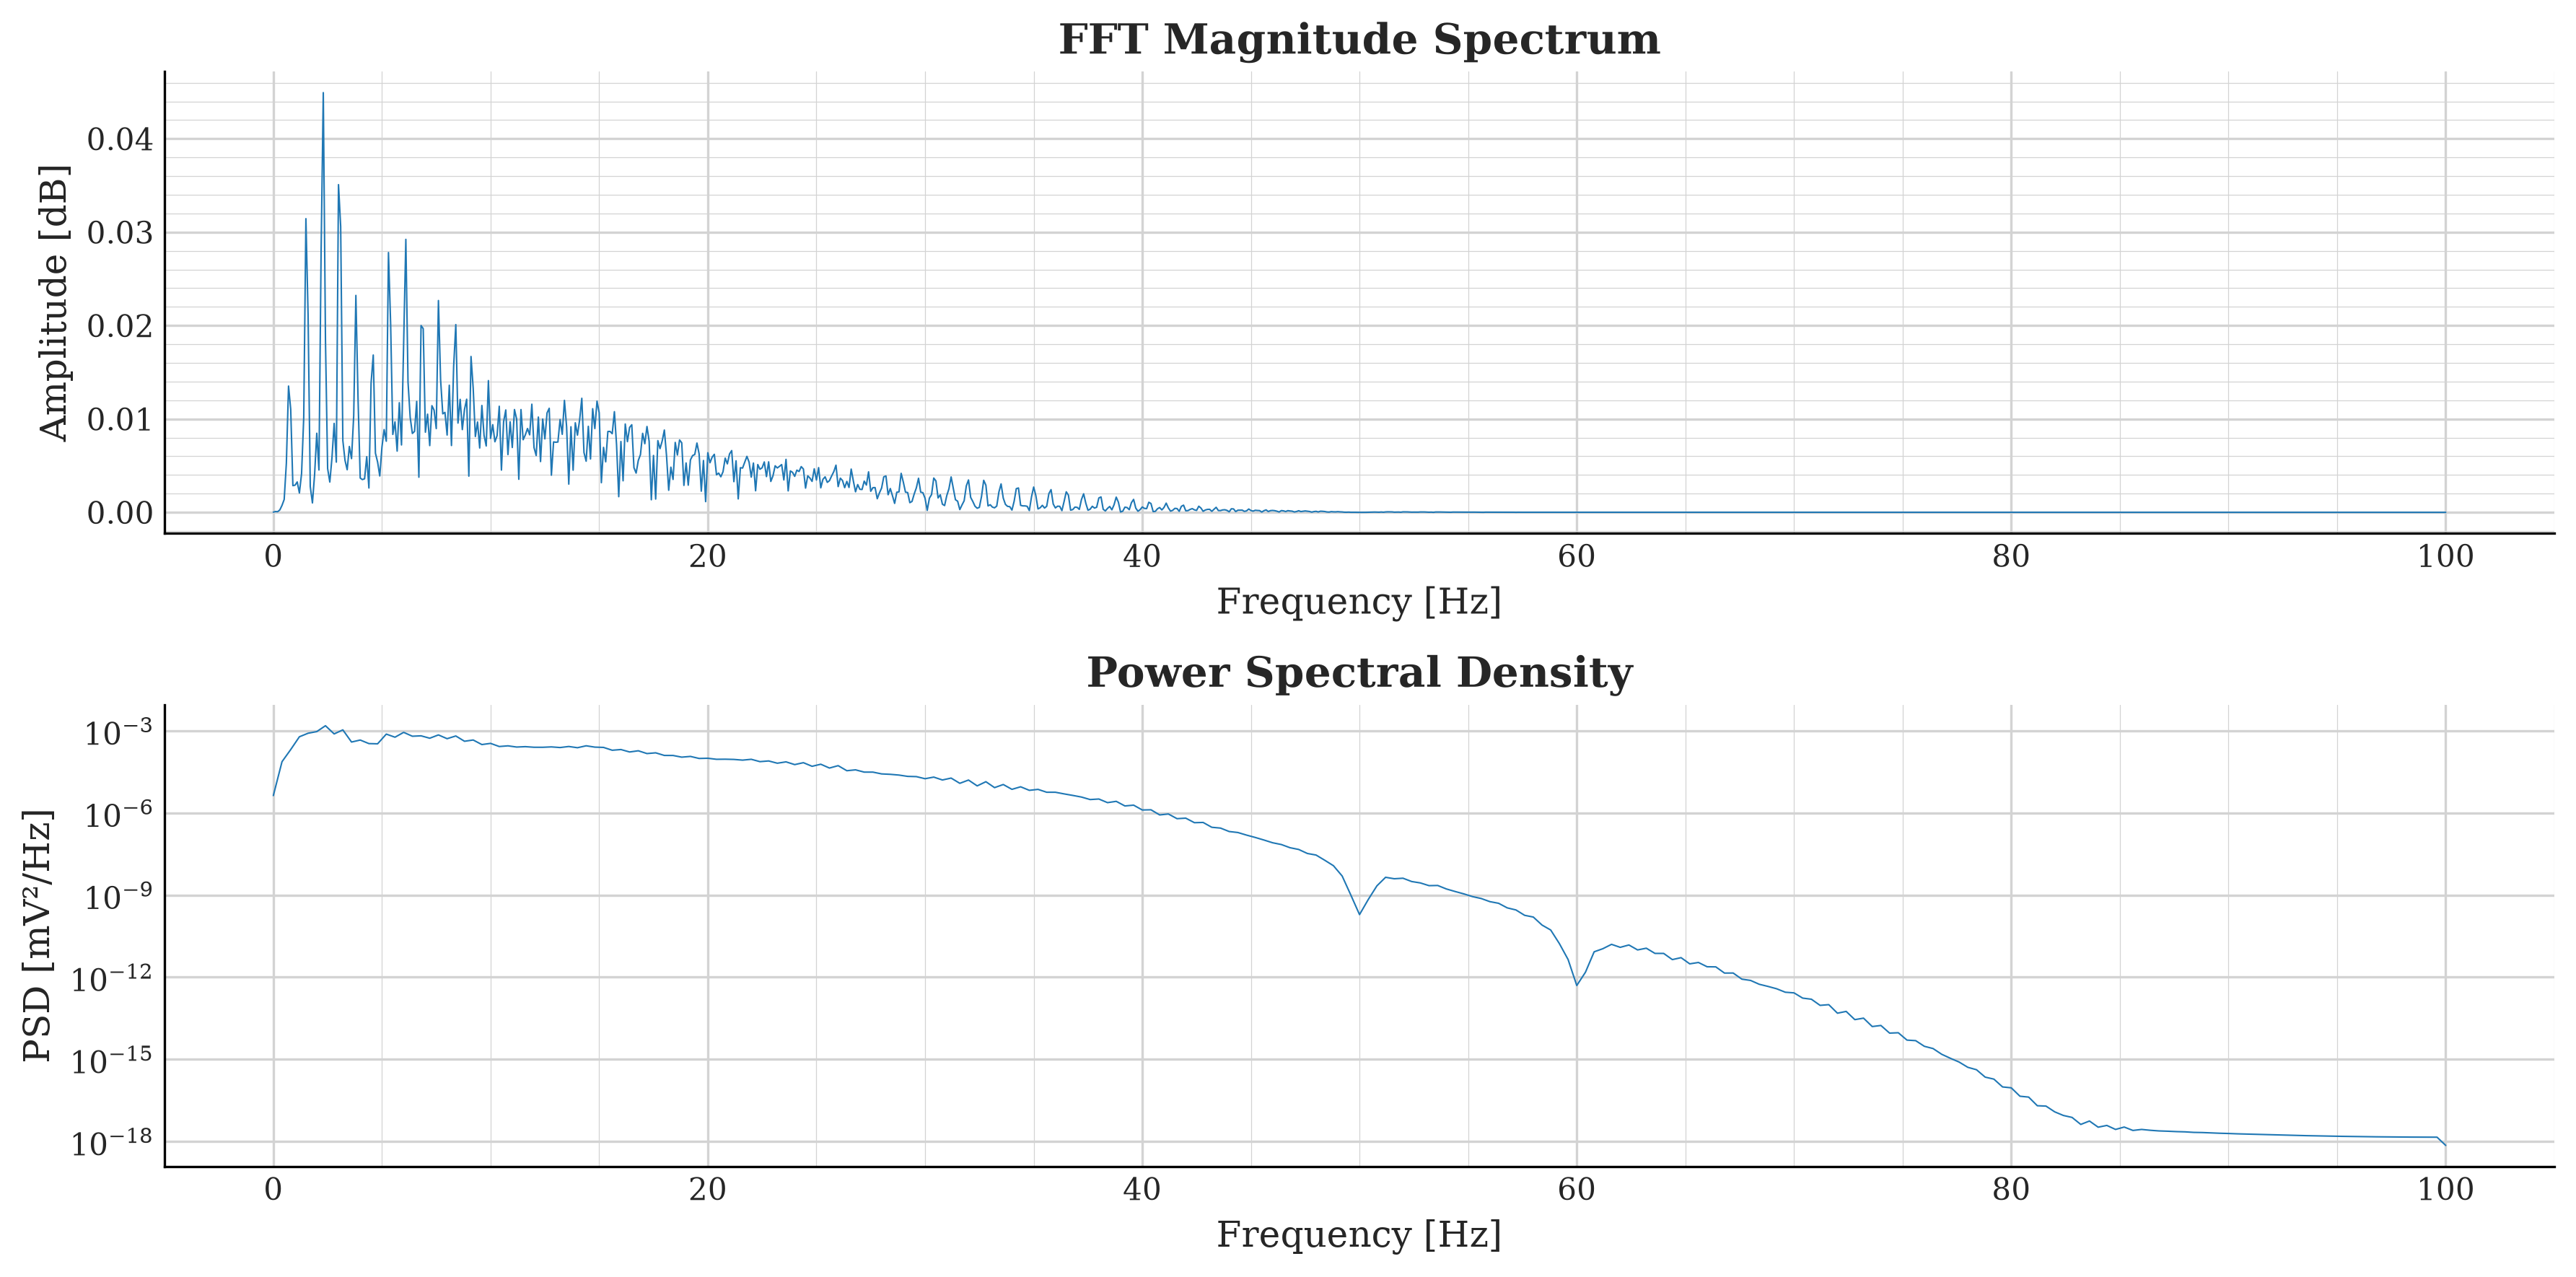

In [54]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

plot_fft(clean_ludb_signal, ax=ax1)
plot_psd(clean_ludb_signal, ax=ax2)

plt.tight_layout()
plt.show()

In [55]:
raw = summarize_signal(ludb_signal)
clean = summarize_signal(clean_ludb_signal)

compare(raw, clean)

Raw                     Clean       
             Property  Value           Property  Value
0           Lead name     ii          Lead name     ii
1    Sample rate (Hz)    200   Sample rate (Hz)    200
2   Number of samples   2000  Number of samples   2000
3        Duration (s)   10.0       Duration (s)   10.0
4            Min (mV) -0.136           Min (mV) -0.141
5            Max (mV)  0.847           Max (mV)  0.754
6           Mean (mV)    0.0          Mean (mV)    0.0
7            Std (mV)  0.096           Std (mV)  0.095
8       Dynamic range  0.983      Dynamic range  0.896
9   Outlier ratio (%)    0.0  Outlier ratio (%)    0.0
10        NaN Samples      0        NaN Samples      0
11      NaN ratio (%)    0.0      NaN ratio (%)    0.0

In [56]:
raw = summarize_signal_quality(ludb_signal)
clean = summarize_signal_quality(clean_ludb_signal)

compare(raw, clean)

Raw                                    Clean  \
                          Property   Value                         Property   
0                     Kurtosis SQI  33.379                     Kurtosis SQI   
1                    QRS Power SQI   0.462                    QRS Power SQI   
2  Powerline Noise Ratio (50.0 Hz)   0.001  Powerline Noise Ratio (50.0 Hz)   
3  Powerline Noise Ratio (60.0 Hz)   0.000  Powerline Noise Ratio (60.0 Hz)   
4            Baseline Wander Ratio   0.028            Baseline Wander Ratio   
5                   Flatline Ratio   0.000                   Flatline Ratio   

           
    Value  
0  29.947  
1   0.469  
2   0.000  
3   0.000  
4   0.024  
5   0.000